<img src="Figures\Logos\Institutions.png" width="800px">


# Supplementary 4
Author code: Jorge Lizarazo





In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
path = r"data\Cloacales\Datos_Nidos_Cloacal_definitivo.csv"

df = pd.read_csv(path)

print(df.shape)
print(df.columns.tolist())
print(df["Especie"].value_counts(dropna=False))
print(df.head())

(307, 15)
['Estacion', 'Especie', 'ID_del_Nido', 'Edad_original', 'Edad', 'Edad_fuente', 'Temp_inicial', 'Temp_final', 'Temp_ambiente', 'Polluelo_Masa_g', 'Polluelo_Masa_g_fuente', 'Polluelo_Tarso_mm', 'Polluelo_Tarso_mm_fuente', 'Polluelo_Ala_mm', 'Polluelo_Ala_mm_fuente']
Especie
Myioborus_miniatus          294
Myioborus_melanocephalus     12
Myioborus_ornatus             1
Name: count, dtype: int64
   Estacion             Especie ID_del_Nido Edad_original  Edad  \
0  Chicoral  Myioborus_miniatus  CH06_AMM15           NaN     2   
1  Chicoral  Myioborus_miniatus  CH06_AMM15           NaN     1   
2  Chicoral  Myioborus_miniatus  CH06_AMM15           NaN     2   
3  Chicoral  Myioborus_miniatus  CH06_AMM15           NaN     2   
4  Chicoral  Myioborus_miniatus  CH06_AMM15           NaN     2   

             Edad_fuente  Temp_inicial  Temp_final  Temp_ambiente  \
0  rf_from_morphometrics        28.072      26.378          21.92   
1  rf_from_morphometrics        28.642      24.122    

In [3]:
# Remove ornatus
df = df[df["Especie"] != "Myioborus_ornatus"].copy()

In [4]:
numeric_cols = [
    "Edad",
    "Temp_inicial",
    "Temp_final",
    "Temp_ambiente",
    "Polluelo_Masa_g",
    "Polluelo_Tarso_mm",
    "Polluelo_Ala_mm"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove incomplete rows for this analysis
df = df.dropna(
    subset=[
        "Especie",
        "ID_del_Nido",
        "Edad",
        "Temp_inicial",
        "Temp_final",
        "Temp_ambiente",
        "Polluelo_Masa_g",
        "Polluelo_Tarso_mm",
        "Polluelo_Ala_mm"
    ]
).copy()

# Thermal variables
df["thermal_gradient_initial"] = df["Temp_inicial"] - df["Temp_ambiente"]

# Positive values = cooling; negative values = warming over the 3-min interval
df["cooling_magnitude_C_min"] = (df["Temp_inicial"] - df["Temp_final"]) / 3

df["delta_T_3min"] = df["Temp_final"] - df["Temp_inicial"]

print(df.shape)
print(df["Especie"].value_counts())
print(df[["Temp_inicial", "Temp_final", "Temp_ambiente",
          "thermal_gradient_initial", "cooling_magnitude_C_min"]].describe())

(306, 18)
Especie
Myioborus_miniatus          294
Myioborus_melanocephalus     12
Name: count, dtype: int64
       Temp_inicial  Temp_final  Temp_ambiente  thermal_gradient_initial  \
count    306.000000  306.000000     306.000000                306.000000   
mean      35.652268   33.363778      20.028556                 15.623712   
std        3.286821    4.121688       3.343727                  3.675039   
min       21.580000   19.400000      11.500000                 -0.185000   
25%       33.495250   30.379250      17.825000                 13.331000   
50%       35.998500   33.809000      19.820000                 15.968000   
75%       38.032000   36.755500      21.912500                 18.124500   
max       41.972000   41.560000      35.180000                 24.571000   

       cooling_magnitude_C_min  
count               306.000000  
mean                  0.762830  
std                   0.673884  
min                  -2.670000  
25%                   0.301833  
50%      

In [8]:


# Remove incomplete rows for the mass-based analysis only
df = df.dropna(
    subset=[
        "Especie",
        "ID_del_Nido",
        "Edad",
        "Temp_inicial",
        "Temp_final",
        "Temp_ambiente",
        "Polluelo_Masa_g"
    ]
).copy()

In [9]:
# Thermal variables
df["thermal_gradient_initial"] = df["Temp_inicial"] - df["Temp_ambiente"]

# Positive values = cooling; negative values = warming over the 3-min interval
df["cooling_magnitude_C_min"] = (df["Temp_inicial"] - df["Temp_final"]) / 3

df["delta_T_3min"] = df["Temp_final"] - df["Temp_inicial"]

print(df.shape)
print(df["Especie"].value_counts())
print(df[[
    "Edad",
    "Polluelo_Masa_g",
    "Temp_inicial",
    "Temp_final",
    "Temp_ambiente",
    "thermal_gradient_initial",
    "cooling_magnitude_C_min"
]].describe())

(306, 18)
Especie
Myioborus_miniatus          294
Myioborus_melanocephalus     12
Name: count, dtype: int64
             Edad  Polluelo_Masa_g  Temp_inicial  Temp_final  Temp_ambiente  \
count  306.000000       306.000000    306.000000  306.000000     306.000000   
mean     5.437908         6.754905     35.652268   33.363778      20.028556   
std      2.934990         2.898387      3.286821    4.121688       3.343727   
min      1.000000         1.330000     21.580000   19.400000      11.500000   
25%      3.000000         4.182500     33.495250   30.379250      17.825000   
50%      5.000000         7.335000     35.998500   33.809000      19.820000   
75%      7.750000         9.380000     38.032000   36.755500      21.912500   
max     12.000000        13.630000     41.972000   41.560000      35.180000   

       thermal_gradient_initial  cooling_magnitude_C_min  
count                306.000000               306.000000  
mean                  15.623712                 0.762830  
std

In [10]:
print(df[["Edad", "Polluelo_Masa_g", "thermal_gradient_initial", "cooling_magnitude_C_min"]].corr())

                              Edad  Polluelo_Masa_g  thermal_gradient_initial  \
Edad                      1.000000         0.762424                  0.399722   
Polluelo_Masa_g           0.762424         1.000000                  0.539216   
thermal_gradient_initial  0.399722         0.539216                  1.000000   
cooling_magnitude_C_min  -0.342994        -0.341848                  0.054771   

                          cooling_magnitude_C_min  
Edad                                    -0.342994  
Polluelo_Masa_g                         -0.341848  
thermal_gradient_initial                 0.054771  
cooling_magnitude_C_min                  1.000000  


In [12]:
df_model = df.copy()

print("Model dataset shape:", df_model.shape)

print("\nSpecies included:")
print(df_model["Especie"].value_counts())

print("\nNumber of nests:")
print(df_model["ID_del_Nido"].nunique())

print("\nObservations per nest:")
print(df_model.groupby("ID_del_Nido").size().describe())

Model dataset shape: (306, 18)

Species included:
Especie
Myioborus_miniatus          294
Myioborus_melanocephalus     12
Name: count, dtype: int64

Number of nests:
52

Observations per nest:
count    52.000000
mean      5.884615
std       4.332521
min       1.000000
25%       2.750000
50%       4.000000
75%       8.000000
max      19.000000
dtype: float64


In [13]:
df_model["Edad_c"] = df_model["Edad"] - df_model["Edad"].mean()

df_model["thermal_gradient_initial_c"] = (
    df_model["thermal_gradient_initial"] - df_model["thermal_gradient_initial"].mean()
)

df_model["Polluelo_Masa_g_c"] = (
    df_model["Polluelo_Masa_g"] - df_model["Polluelo_Masa_g"].mean()
)

print(df_model[[
    "cooling_magnitude_C_min",
    "thermal_gradient_initial_c",
    "Edad_c",
    "Polluelo_Masa_g_c"
]].describe())

       cooling_magnitude_C_min  thermal_gradient_initial_c        Edad_c  \
count               306.000000                3.060000e+02  3.060000e+02   
mean                  0.762830                1.625425e-15 -2.438137e-16   
std                   0.673884                3.675039e+00  2.934990e+00   
min                  -2.670000               -1.580871e+01 -4.437908e+00   
25%                   0.301833               -2.292712e+00 -2.437908e+00   
50%                   0.680500                3.442876e-01 -4.379085e-01   
75%                   1.153333                2.500788e+00  2.312092e+00   
max                   4.233000                8.947288e+00  6.562092e+00   

       Polluelo_Masa_g_c  
count       3.060000e+02  
mean        1.625425e-16  
std         2.898387e+00  
min        -5.424905e+00  
25%        -2.572405e+00  
50%         5.800946e-01  
75%         2.625095e+00  
max         6.875095e+00  


In [15]:
nest_counts = df_model.groupby("ID_del_Nido").size().sort_values()

print(nest_counts)
print("\nSummary:")
print(nest_counts.describe())

print("\nNests with only one observation:")
print(nest_counts[nest_counts == 1])

ID_del_Nido
TA05_SG15       1
TA30_ROAD15     1
TA21_DB15       1
TA21_CAB15      1
TA13_JH15       2
DA01_MMC18      2
TA13_JGMM14     2
FA07_KTN15      2
TA18_MCD14      2
W11_DAR12       2
TA41_MASM14     2
TA45_ROAD15     2
TA07_RA14       2
TA27_DB15       3
FA06_KTN15      3
SP02_JSP13      3
TA35_ROAD15     3
TA11_DB15       4
SP12_RVA10      4
TA05_ROAD15     4
TA27_ROAD15     4
TA50_ROAD15     4
TA29_AMB15      4
W6_AOQ11        4
FA03_KTN15      4
TA15_EJ15       4
TA09_GJDR14     4
DA02_MIB18      4
FA04_KTN15      5
TA02_RA15       6
W22_CJS10       6
DA02_LP17       6
TA17_SLS15      6
TA26_MCD14      6
SP4_EJW11       7
CH14_AMM15      7
SP01_DAR11      7
TA12_JGMM14     7
TA19_MCD14      8
CH11_AMM15      8
CH15_MAL15      8
TA23_RVA14      9
TA02_CA15       9
TA37_TRF15     10
FA03_JMM15     10
TA23_JSZ14     11
CH06_AMM15     14
DA01_LP17      14
SP1_EJW11      14
SP01_LJI14     15
CH13_WTF15     16
FA10_JMM15     19
dtype: int64

Summary:
count    52.000000
mean      

In [16]:
# Keep only nests with at least 2 observations
valid_nests = nest_counts[nest_counts >= 2].index

df_model_re = df_model[df_model["ID_del_Nido"].isin(valid_nests)].copy()

print("Original rows:", df_model.shape[0])
print("Rows after keeping nests with >=2 observations:", df_model_re.shape[0])
print("Original nests:", df_model["ID_del_Nido"].nunique())
print("Nests after filtering:", df_model_re["ID_del_Nido"].nunique())

Original rows: 306
Rows after keeping nests with >=2 observations: 302
Original nests: 52
Nests after filtering: 48


In [17]:
df_model_re["Edad_c"] = df_model_re["Edad"] - df_model_re["Edad"].mean()

df_model_re["thermal_gradient_initial_c"] = (
    df_model_re["thermal_gradient_initial"] - df_model_re["thermal_gradient_initial"].mean()
)

df_model_re["Polluelo_Masa_g_c"] = (
    df_model_re["Polluelo_Masa_g"] - df_model_re["Polluelo_Masa_g"].mean()
)

In [18]:
model_cooling_mass_simple = smf.mixedlm(
    "cooling_magnitude_C_min ~ thermal_gradient_initial_c + Edad_c + Polluelo_Masa_g_c",
    data=df_model_re,
    groups=df_model_re["ID_del_Nido"]
)

result_cooling_mass_simple = model_cooling_mass_simple.fit(
    reml=False,
    method="powell"
)

print(result_cooling_mass_simple.summary())

                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: cooling_magnitude_C_min
No. Observations: 302     Method:             ML                     
No. Groups:       48      Scale:              0.3165                 
Min. group size:  2       Log-Likelihood:     -268.5165              
Max. group size:  19      Converged:          Yes                    
Mean group size:  6.3                                                
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.752    0.046 16.233 0.000  0.661  0.843
thermal_gradient_initial_c  0.067    0.012  5.587 0.000  0.043  0.090
Edad_c                     -0.045    0.021 -2.187 0.029 -0.085 -0.005
Polluelo_Masa_g_c          -0.089    0.022 -3.958 0.000 -0.133 -0.045
Group Var                   0.042   

In [19]:
model_cooling_mass_interaction = smf.mixedlm(
    "cooling_magnitude_C_min ~ thermal_gradient_initial_c * Edad_c + Polluelo_Masa_g_c",
    data=df_model_re,
    groups=df_model_re["ID_del_Nido"]
)

result_cooling_mass_interaction = model_cooling_mass_interaction.fit(
    reml=False,
    method="powell"
)

print(result_cooling_mass_interaction.summary())

                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   cooling_magnitude_C_min
No. Observations:    302       Method:               ML                     
No. Groups:          48        Scale:                0.3157                 
Min. group size:     2         Log-Likelihood:       -268.2645              
Max. group size:     19        Converged:            Yes                    
Mean group size:     6.3                                                    
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          0.742    0.049 15.225 0.000  0.646  0.837
thermal_gradient_initial_c         0.068    0.012  5.631 0.000  0.044  0.091
Edad_c                            -0.048    0.021 -2.284 0.022 -0.089 -0.007
thermal_gradient_in

In [20]:
print("Simple model AIC:", result_cooling_mass_simple.aic)
print("Interaction model AIC:", result_cooling_mass_interaction.aic)
print("Delta AIC simple - interaction:", result_cooling_mass_simple.aic - result_cooling_mass_interaction.aic)

Simple model AIC: 549.033040774209
Interaction model AIC: 550.5289473606267
Delta AIC simple - interaction: -1.4959065864177319


In [21]:
print(df_model_re[[
    "Edad",
    "Polluelo_Masa_g",
    "thermal_gradient_initial",
    "cooling_magnitude_C_min"
]].corr())

                              Edad  Polluelo_Masa_g  thermal_gradient_initial  \
Edad                      1.000000         0.759984                  0.397214   
Polluelo_Masa_g           0.759984         1.000000                  0.536180   
thermal_gradient_initial  0.397214         0.536180                  1.000000   
cooling_magnitude_C_min  -0.344063        -0.342165                  0.059555   

                          cooling_magnitude_C_min  
Edad                                    -0.344063  
Polluelo_Masa_g                         -0.342165  
thermal_gradient_initial                 0.059555  
cooling_magnitude_C_min                  1.000000  


In [22]:
model_age_interaction = smf.mixedlm(
    "cooling_magnitude_C_min ~ thermal_gradient_initial_c * Edad_c",
    data=df_model_re,
    groups=df_model_re["ID_del_Nido"]
)

result_age_interaction = model_age_interaction.fit(
    reml=False,
    method="powell"
)

print(result_age_interaction.summary())

                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   cooling_magnitude_C_min
No. Observations:    302       Method:               ML                     
No. Groups:          48        Scale:                0.3261                 
Min. group size:     2         Log-Likelihood:       -275.1150              
Max. group size:     19        Converged:            Yes                    
Mean group size:     6.3                                                    
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          0.729    0.052 14.151 0.000  0.628  0.830
thermal_gradient_initial_c         0.053    0.012  4.514 0.000  0.030  0.076
Edad_c                            -0.109    0.014 -7.882 0.000 -0.137 -0.082
thermal_gradient_in

In [23]:
model_mass_interaction = smf.mixedlm(
    "cooling_magnitude_C_min ~ thermal_gradient_initial_c * Polluelo_Masa_g_c",
    data=df_model_re,
    groups=df_model_re["ID_del_Nido"]
)

result_mass_interaction = model_mass_interaction.fit(
    reml=False,
    method="powell"
)

print(result_mass_interaction.summary())

                         Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       cooling_magnitude_C_min
No. Observations:       302           Method:                   ML                     
No. Groups:             48            Scale:                    0.3189                 
Min. group size:        2             Log-Likelihood:           -270.8587              
Max. group size:        19            Converged:                Yes                    
Mean group size:        6.3                                                            
---------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                     0.755    0.052 14.638 0.000  0.654  0.856
thermal_gradient_initial_c                    0.067    0.

In [24]:
model_comp = pd.DataFrame({
    "model": [
        "simple_age_mass",
        "interaction_age_mass",
        "age_interaction",
        "mass_interaction"
    ],
    "AIC": [
        result_cooling_mass_simple.aic,
        result_cooling_mass_interaction.aic,
        result_age_interaction.aic,
        result_mass_interaction.aic
    ]
})

model_comp["delta_AIC"] = model_comp["AIC"] - model_comp["AIC"].min()
print(model_comp.sort_values("AIC"))

                  model         AIC  delta_AIC
0       simple_age_mass  549.033041   0.000000
1  interaction_age_mass  550.528947   1.495907
3      mass_interaction  553.717345   4.684304
2       age_interaction  562.230019  13.196978


In [25]:
preferred_model = result_cooling_mass_simple
#cooling_magnitude_C_min ~ thermal_gradient_initial_c + Edad_c + Polluelo_Masa_g_c + (1 | ID_del_Nido)
print(preferred_model.summary())

                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: cooling_magnitude_C_min
No. Observations: 302     Method:             ML                     
No. Groups:       48      Scale:              0.3165                 
Min. group size:  2       Log-Likelihood:     -268.5165              
Max. group size:  19      Converged:          Yes                    
Mean group size:  6.3                                                
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.752    0.046 16.233 0.000  0.661  0.843
thermal_gradient_initial_c  0.067    0.012  5.587 0.000  0.043  0.090
Edad_c                     -0.045    0.021 -2.187 0.029 -0.085 -0.005
Polluelo_Masa_g_c          -0.089    0.022 -3.958 0.000 -0.133 -0.045
Group Var                   0.042   

In [26]:
fixed_effects = pd.DataFrame({
    "estimate": preferred_model.params,
    "std_error": preferred_model.bse,
    "z_value": preferred_model.tvalues,
    "p_value": preferred_model.pvalues
})

print(fixed_effects)

                            estimate  std_error    z_value       p_value
Intercept                   0.752245   0.046340  16.233087  2.942804e-59
thermal_gradient_initial_c  0.066557   0.011913   5.586710  2.314113e-08
Edad_c                     -0.045030   0.020592  -2.186769  2.875938e-02
Polluelo_Masa_g_c          -0.088889   0.022455  -3.958458  7.543535e-05
Group Var                   0.134016   0.067293   1.991529  4.642274e-02


In [27]:
nest_var = preferred_model.cov_re.iloc[0, 0]
resid_var = preferred_model.scale

icc = nest_var / (nest_var + resid_var)

print("Nest random-effect variance:", nest_var)
print("Residual variance:", resid_var)
print("Approximate ICC:", icc)

Nest random-effect variance: 0.042422502014265416
Residual variance: 0.3165490358254584
Approximate ICC: 0.11817789864222193


In [28]:
random_effects = preferred_model.random_effects

re_df = pd.DataFrame({
    "ID_del_Nido": list(random_effects.keys()),
    "random_intercept": [float(v.iloc[0]) for v in random_effects.values()]
})

re_df = re_df.sort_values("random_intercept")

nest_info = (
    df_model_re[["ID_del_Nido", "Especie", "Estacion", "Edad", "Polluelo_Masa_g"]]
    .groupby("ID_del_Nido")
    .agg(
        Especie=("Especie", "first"),
        Estacion=("Estacion", "first"),
        mean_age=("Edad", "mean"),
        mean_mass=("Polluelo_Masa_g", "mean"),
        n_obs=("Edad", "size")
    )
    .reset_index()
)

re_df_info = re_df.merge(nest_info, on="ID_del_Nido", how="left")

print("Nests cooling less than expected:")
print(re_df_info.head(10))

print("\nNests cooling more than expected:")
print(re_df_info.tail(10))

Nests cooling less than expected:
   ID_del_Nido  random_intercept             Especie Estacion  mean_age  \
0    DA01_LP17         -0.246705  Myioborus_miniatus  Danubio  4.214286   
1   TA17_SLS15         -0.196807  Myioborus_miniatus   Tatama  4.333333   
2  TA50_ROAD15         -0.167881  Myioborus_miniatus   Tatama  6.500000   
3    DA02_LP17         -0.163694  Myioborus_miniatus  Danubio  5.166667   
4  TA41_MASM14         -0.154579  Myioborus_miniatus   Tatama  4.000000   
5   TA29_AMB15         -0.150996  Myioborus_miniatus   Tatama  3.500000   
6    TA02_RA15         -0.136142  Myioborus_miniatus   Tatama  8.333333   
7  TA09_GJDR14         -0.124463  Myioborus_miniatus   Tatama  1.500000   
8  TA35_ROAD15         -0.124280  Myioborus_miniatus   Tatama  6.333333   
9   TA19_MCD14         -0.122773  Myioborus_miniatus   Tatama  5.750000   

   mean_mass  n_obs  
0   7.429286     14  
1   6.220000      6  
2   6.567500      4  
3   8.623333      6  
4   1.375000      2  
5   5.58

In [29]:
nest_var = preferred_model.cov_re.iloc[0, 0]
resid_var = preferred_model.scale
icc = nest_var / (nest_var + resid_var)

print("Nest variance:", nest_var)
print("Residual variance:", resid_var)
print("Approximate ICC:", icc)

Nest variance: 0.042422502014265416
Residual variance: 0.3165490358254584
Approximate ICC: 0.11817789864222193


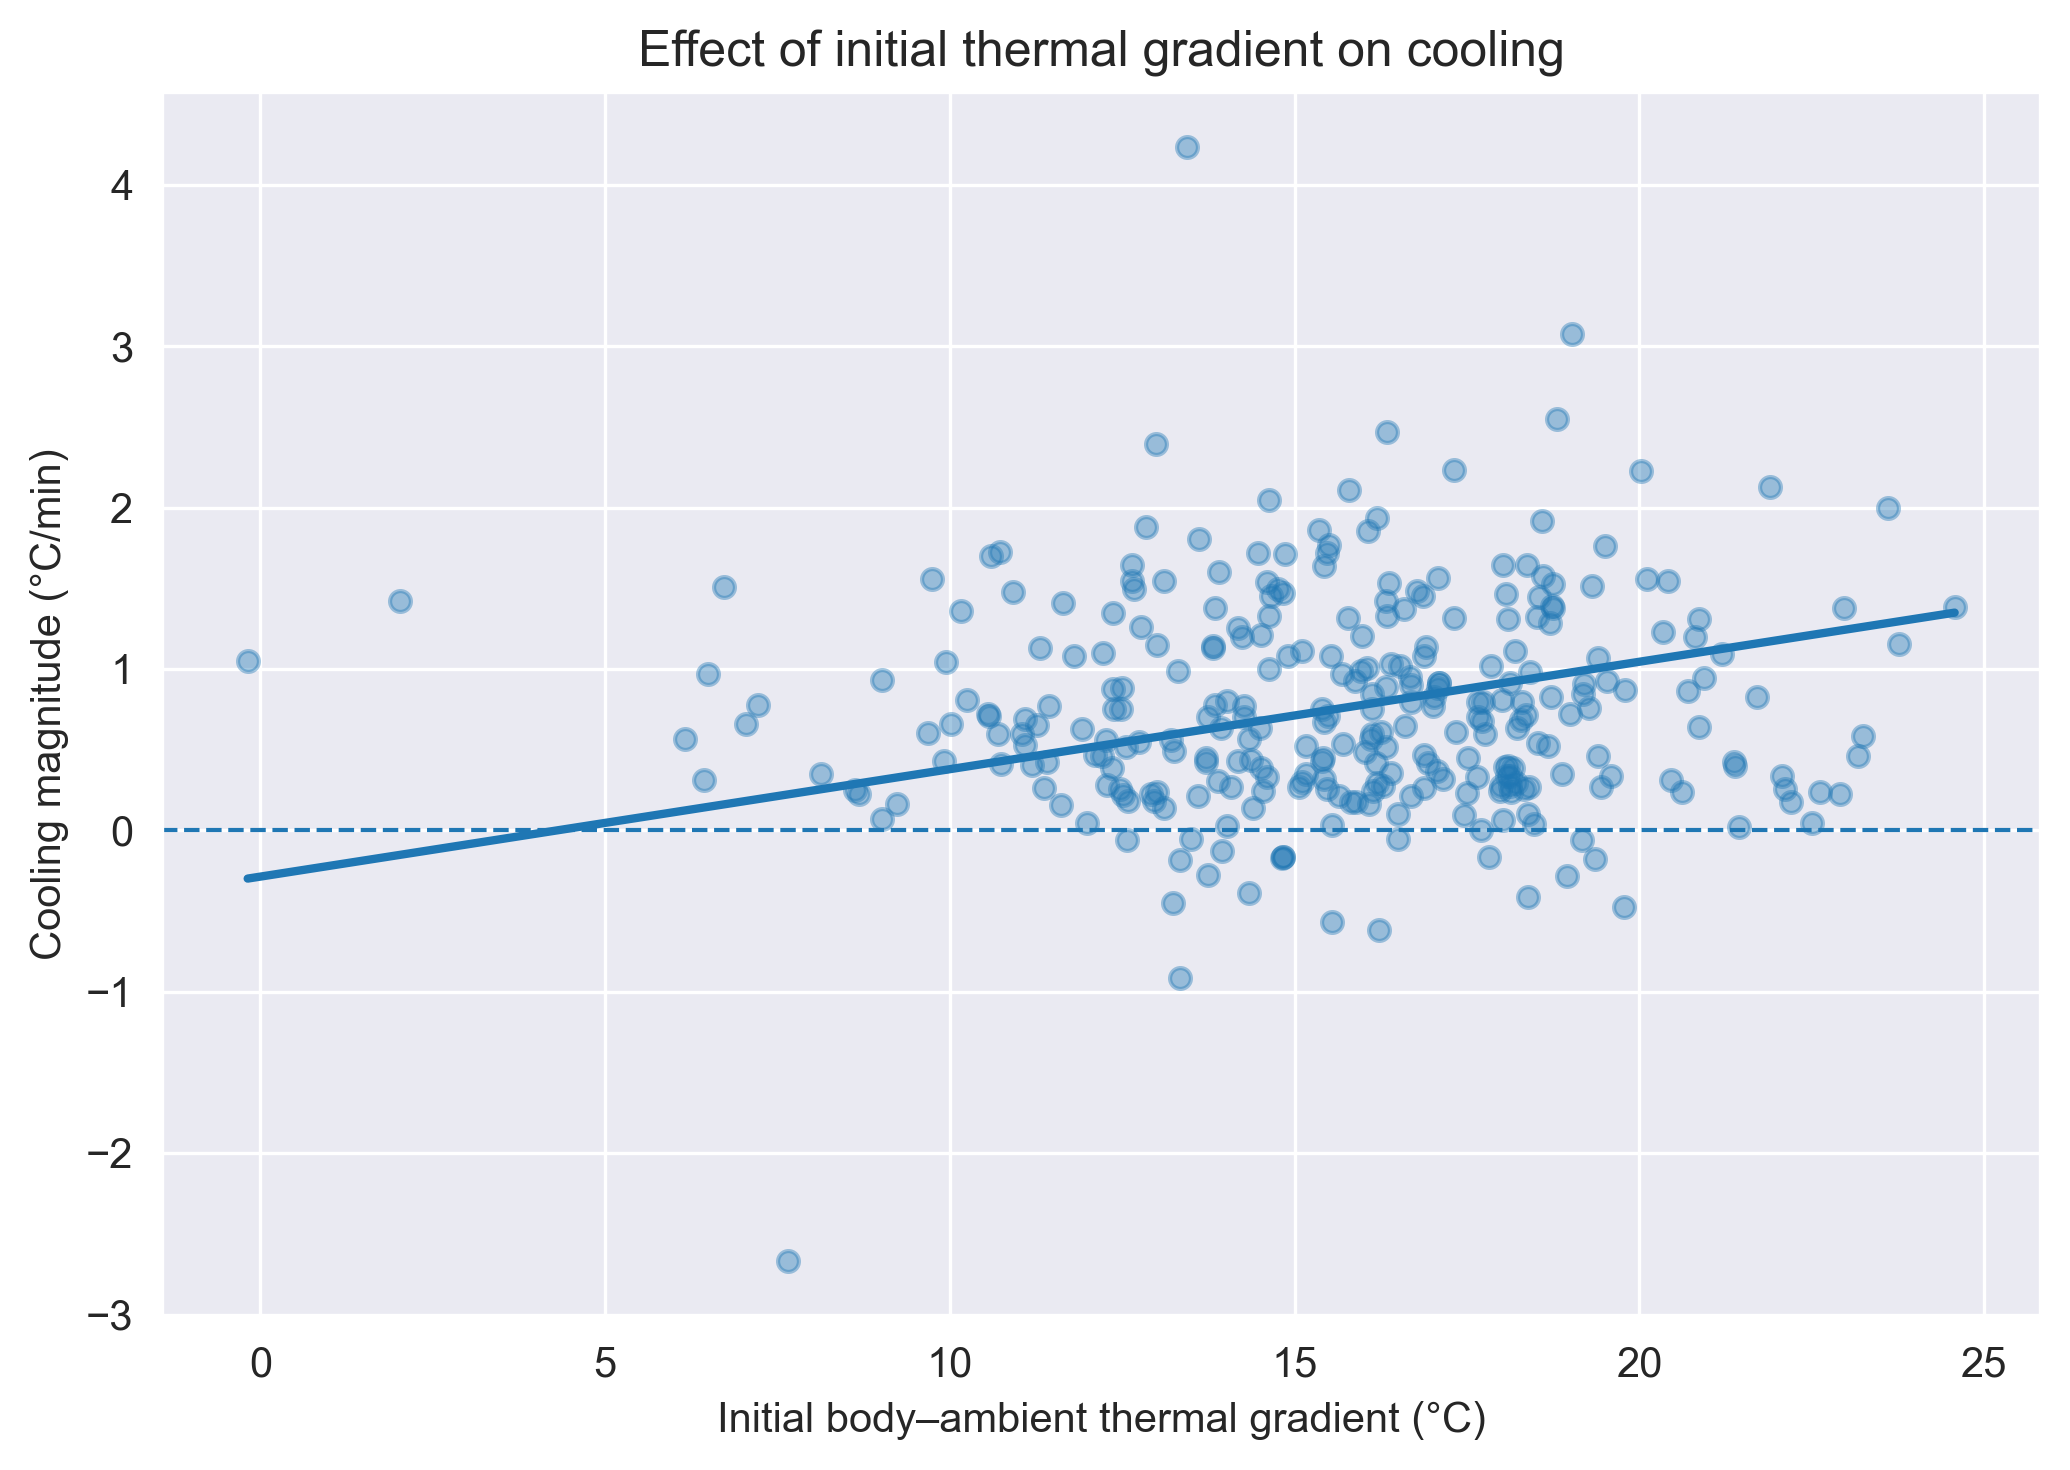

In [30]:
# Plot 1: effect of initial thermal gradient
# ============================================================

gradient_seq = np.linspace(
    df_model_re["thermal_gradient_initial_c"].min(),
    df_model_re["thermal_gradient_initial_c"].max(),
    100
)

pred_gradient = pd.DataFrame({
    "thermal_gradient_initial_c": gradient_seq,
    "Edad_c": 0,
    "Polluelo_Masa_g_c": 0
})

# Back-transform to original scale for plotting
pred_gradient["thermal_gradient_initial"] = (
    pred_gradient["thermal_gradient_initial_c"] +
    df_model_re["thermal_gradient_initial"].mean()
)

pred_gradient["pred"] = preferred_model.predict(pred_gradient)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.scatter(
    df_model_re["thermal_gradient_initial"],
    df_model_re["cooling_magnitude_C_min"],
    alpha=0.4,
    s=25
)

ax.plot(
    pred_gradient["thermal_gradient_initial"],
    pred_gradient["pred"],
    linewidth=2
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Initial body–ambient thermal gradient (°C)")
ax.set_ylabel("Cooling magnitude (°C/min)")
ax.set_title("Effect of initial thermal gradient on cooling")

plt.tight_layout()
plt.savefig(
    "Figures/cloacal_cooling_effect_gradient.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()

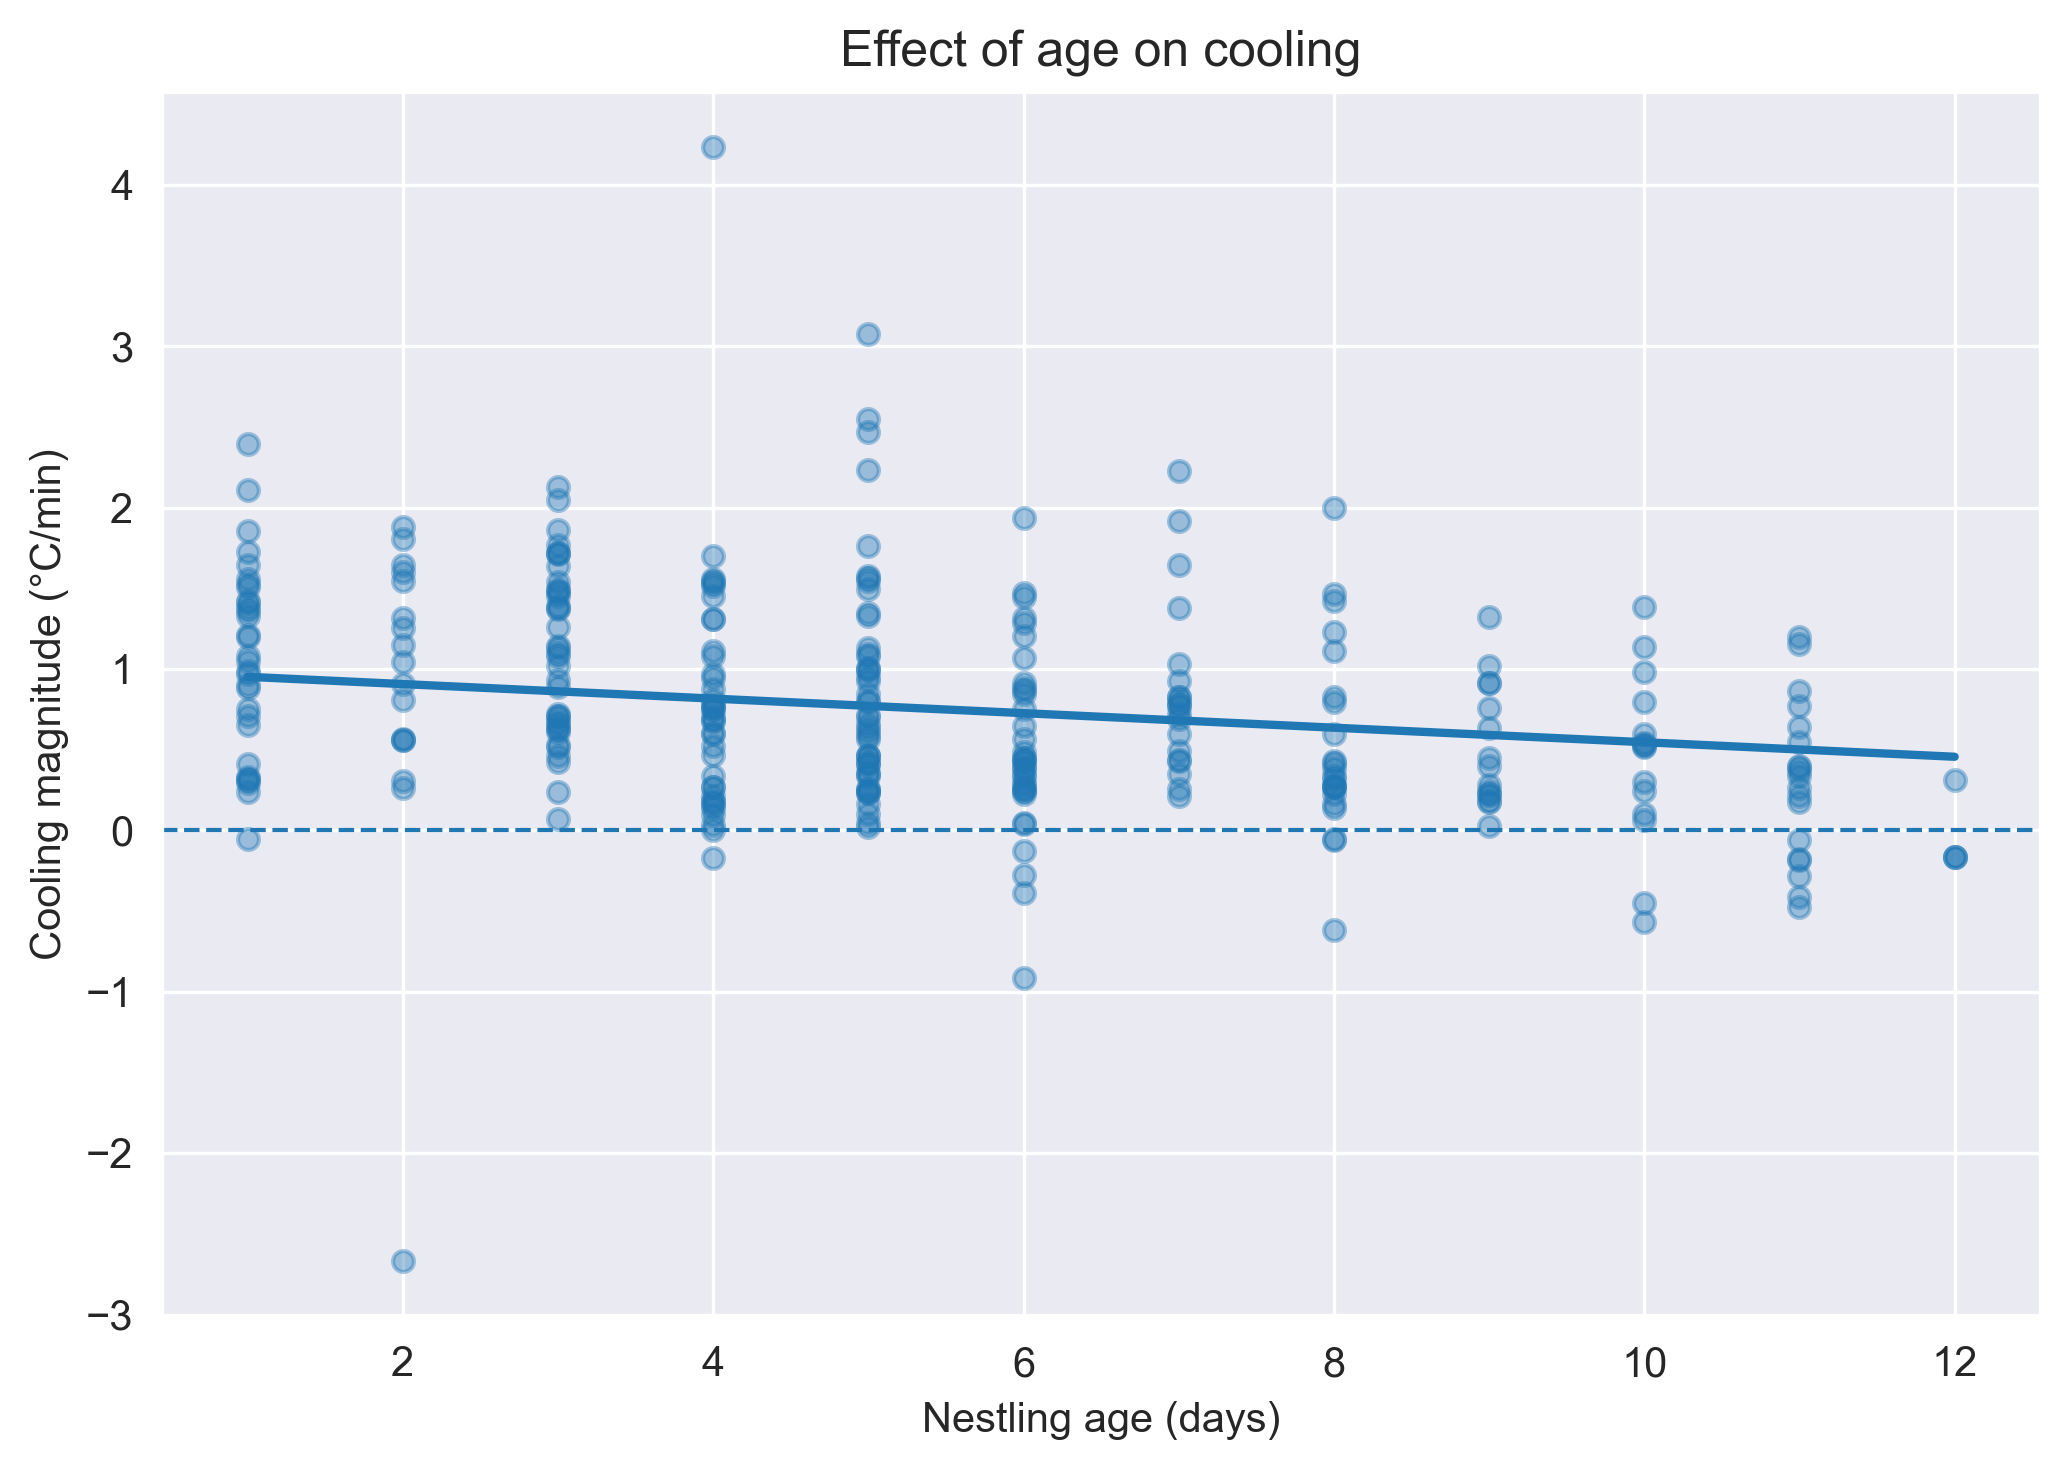

In [31]:
age_seq = np.linspace(
    df_model_re["Edad_c"].min(),
    df_model_re["Edad_c"].max(),
    100
)

pred_age = pd.DataFrame({
    "thermal_gradient_initial_c": 0,
    "Edad_c": age_seq,
    "Polluelo_Masa_g_c": 0
})

# Back-transform to original scale
pred_age["Edad"] = pred_age["Edad_c"] + df_model_re["Edad"].mean()
pred_age["pred"] = preferred_model.predict(pred_age)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.scatter(
    df_model_re["Edad"],
    df_model_re["cooling_magnitude_C_min"],
    alpha=0.4,
    s=25
)

ax.plot(
    pred_age["Edad"],
    pred_age["pred"],
    linewidth=2
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Nestling age (days)")
ax.set_ylabel("Cooling magnitude (°C/min)")
ax.set_title("Effect of age on cooling")

plt.tight_layout()
plt.savefig(
    "Figures/cloacal_cooling_effect_age.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()

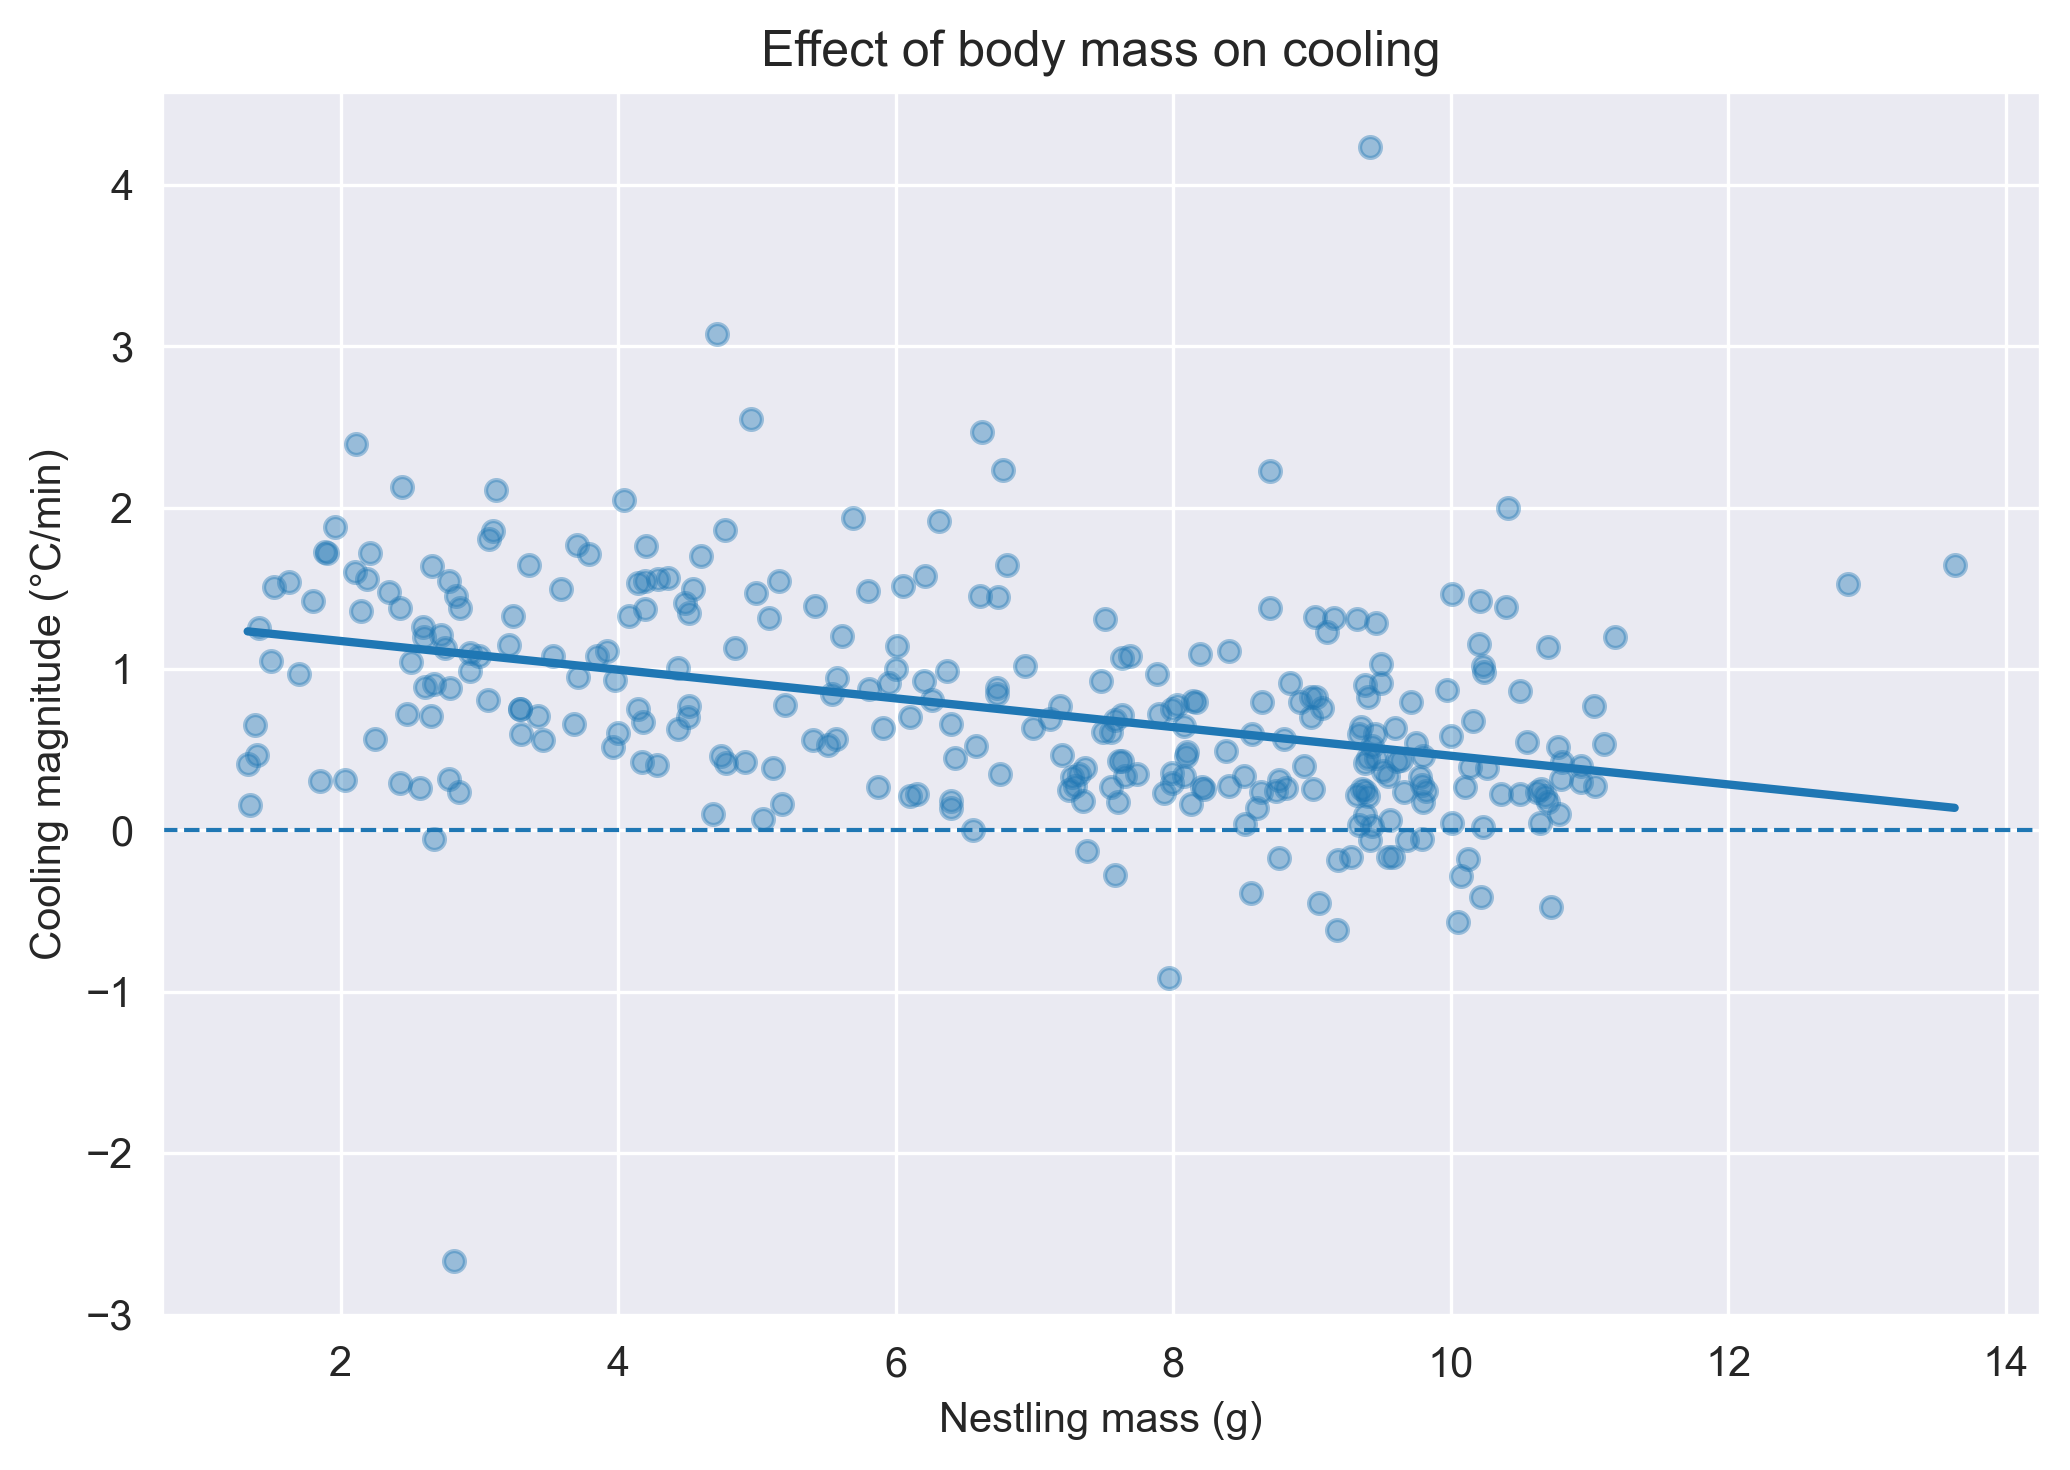

In [32]:
# Plot 3: effect of body mass
# ============================================================

mass_seq = np.linspace(
    df_model_re["Polluelo_Masa_g_c"].min(),
    df_model_re["Polluelo_Masa_g_c"].max(),
    100
)

pred_mass = pd.DataFrame({
    "thermal_gradient_initial_c": 0,
    "Edad_c": 0,
    "Polluelo_Masa_g_c": mass_seq
})

# Back-transform to original scale
pred_mass["Polluelo_Masa_g"] = (
    pred_mass["Polluelo_Masa_g_c"] +
    df_model_re["Polluelo_Masa_g"].mean()
)

pred_mass["pred"] = preferred_model.predict(pred_mass)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

ax.scatter(
    df_model_re["Polluelo_Masa_g"],
    df_model_re["cooling_magnitude_C_min"],
    alpha=0.4,
    s=25
)

ax.plot(
    pred_mass["Polluelo_Masa_g"],
    pred_mass["pred"],
    linewidth=2
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Nestling mass (g)")
ax.set_ylabel("Cooling magnitude (°C/min)")
ax.set_title("Effect of body mass on cooling")

plt.tight_layout()
plt.savefig(
    "Figures/cloacal_cooling_effect_mass.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()

In [33]:
# Plot settings: species styles
# ============================================================

species_labels = {
    'Myioborus_melanocephalus': 'M. melanocephalus',
    'Myioborus_miniatus': 'M. miniatus',
    'Myioborus_ornatus': 'M. ornatus'
}

species_markers = {
    'Myioborus_melanocephalus': 'o',
    'Myioborus_miniatus': 's',
    'Myioborus_ornatus': 'D'
}

species_colors = {
    'Myioborus_miniatus': "#A7B34C",
    'Myioborus_melanocephalus': "#584CB3",
    'Myioborus_ornatus': "#999999"
}

In [34]:
def predict_mixedlm_ci(model_result, pred_df):
    fe_params = model_result.fe_params
    fe_names = fe_params.index.tolist()

    X = pd.DataFrame(index=pred_df.index)
    X["Intercept"] = 1.0

    for name in fe_names:
        if name == "Intercept":
            continue
        X[name] = pred_df[name]

    X = X[fe_names]

    beta = fe_params.values
    pred = X.values @ beta

    cov_fe = model_result.cov_params().loc[fe_names, fe_names].values
    pred_var = np.sum((X.values @ cov_fe) * X.values, axis=1)
    pred_se = np.sqrt(pred_var)

    pred_df = pred_df.copy()
    pred_df["pred"] = pred
    pred_df["pred_se"] = pred_se
    pred_df["ci_low"] = pred - 1.96 * pred_se
    pred_df["ci_high"] = pred + 1.96 * pred_se

    return pred_df

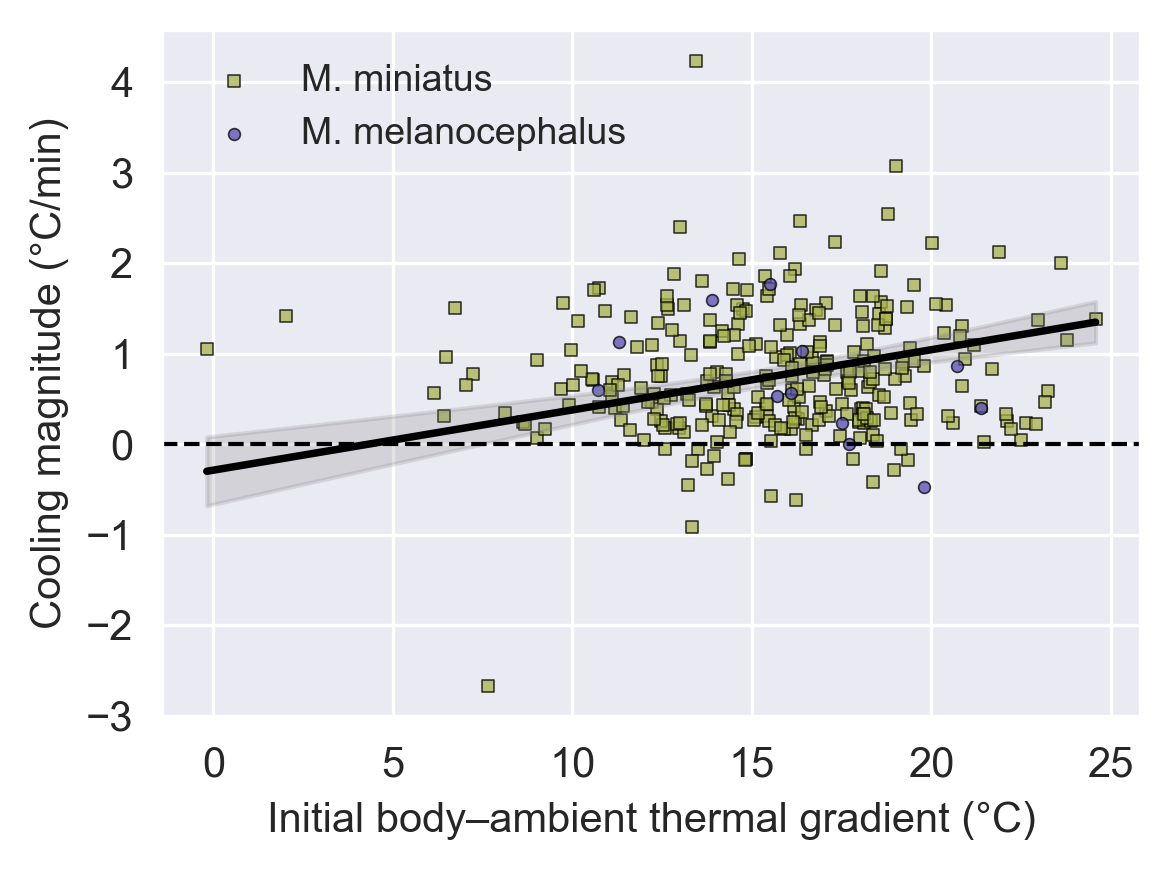

In [49]:
# Plot 1: effect of initial thermal gradient
# ============================================================

gradient_seq = np.linspace(
    df_model_re["thermal_gradient_initial_c"].min(),
    df_model_re["thermal_gradient_initial_c"].max(),
    100
)

pred_gradient = pd.DataFrame({
    "thermal_gradient_initial_c": gradient_seq,
    "Edad_c": 0,
    "Polluelo_Masa_g_c": 0
})

pred_gradient["thermal_gradient_initial"] = (
    pred_gradient["thermal_gradient_initial_c"] +
    df_model_re["thermal_gradient_initial"].mean()
)

pred_gradient = predict_mixedlm_ci(preferred_model, pred_gradient)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Species-specific scatter
for sp in df_model_re["Especie"].dropna().unique():
    sub = df_model_re[df_model_re["Especie"] == sp]
    ax.scatter(
        sub["thermal_gradient_initial"],
        sub["cooling_magnitude_C_min"],
        alpha=0.75,
        s=8,
        marker=species_markers.get(sp, "o"),
        color=species_colors.get(sp, "gray"),
        edgecolor="black",
        linewidth=0.4,
        label=species_labels.get(sp, sp)
    )

# Prediction line + CI
ax.plot(
    pred_gradient["thermal_gradient_initial"],
    pred_gradient["pred"],
    color="black",
    linewidth=1.8
)

ax.fill_between(
    pred_gradient["thermal_gradient_initial"],
    pred_gradient["ci_low"],
    pred_gradient["ci_high"],
    color="gray",
    alpha=0.22
)

ax.axhline(0, linestyle="--", linewidth=1, color="black")

ax.set_xlabel("Initial body–ambient thermal gradient (°C)")
ax.set_ylabel("Cooling magnitude (°C/min)")

ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(
    "Figures/cloacal_cooling_effect_gradient_species.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()

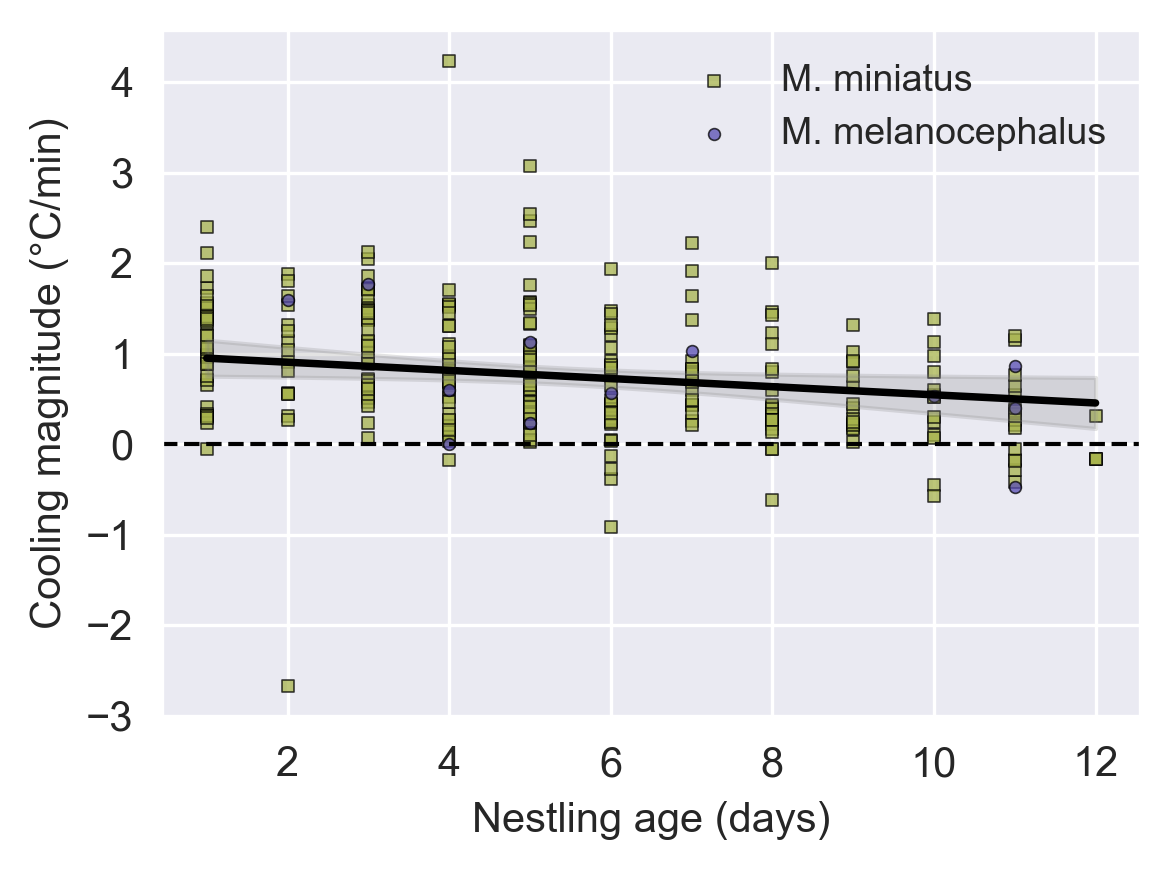

In [48]:
# Plot 2: effect of age
# ============================================================

age_seq = np.linspace(
    df_model_re["Edad_c"].min(),
    df_model_re["Edad_c"].max(),
    100
)

pred_age = pd.DataFrame({
    "thermal_gradient_initial_c": 0,
    "Edad_c": age_seq,
    "Polluelo_Masa_g_c": 0
})

pred_age["Edad"] = pred_age["Edad_c"] + df_model_re["Edad"].mean()
pred_age = predict_mixedlm_ci(preferred_model, pred_age)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

for sp in df_model_re["Especie"].dropna().unique():
    sub = df_model_re[df_model_re["Especie"] == sp]
    ax.scatter(
        sub["Edad"],
        sub["cooling_magnitude_C_min"],
        alpha=0.75,
        s=8,
        marker=species_markers.get(sp, "o"),
        color=species_colors.get(sp, "gray"),
        edgecolor="black",
        linewidth=0.4,
        label=species_labels.get(sp, sp)
    )

ax.plot(
    pred_age["Edad"],
    pred_age["pred"],
    color="black",
    linewidth=1.8
)

ax.fill_between(
    pred_age["Edad"],
    pred_age["ci_low"],
    pred_age["ci_high"],
    color="gray",
    alpha=0.22
)

ax.axhline(0, linestyle="--", linewidth=1, color="black")

ax.set_xlabel("Nestling age (days)")
ax.set_ylabel("Cooling magnitude (°C/min)")

ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(
    "Figures/cloacal_cooling_effect_age_species.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()

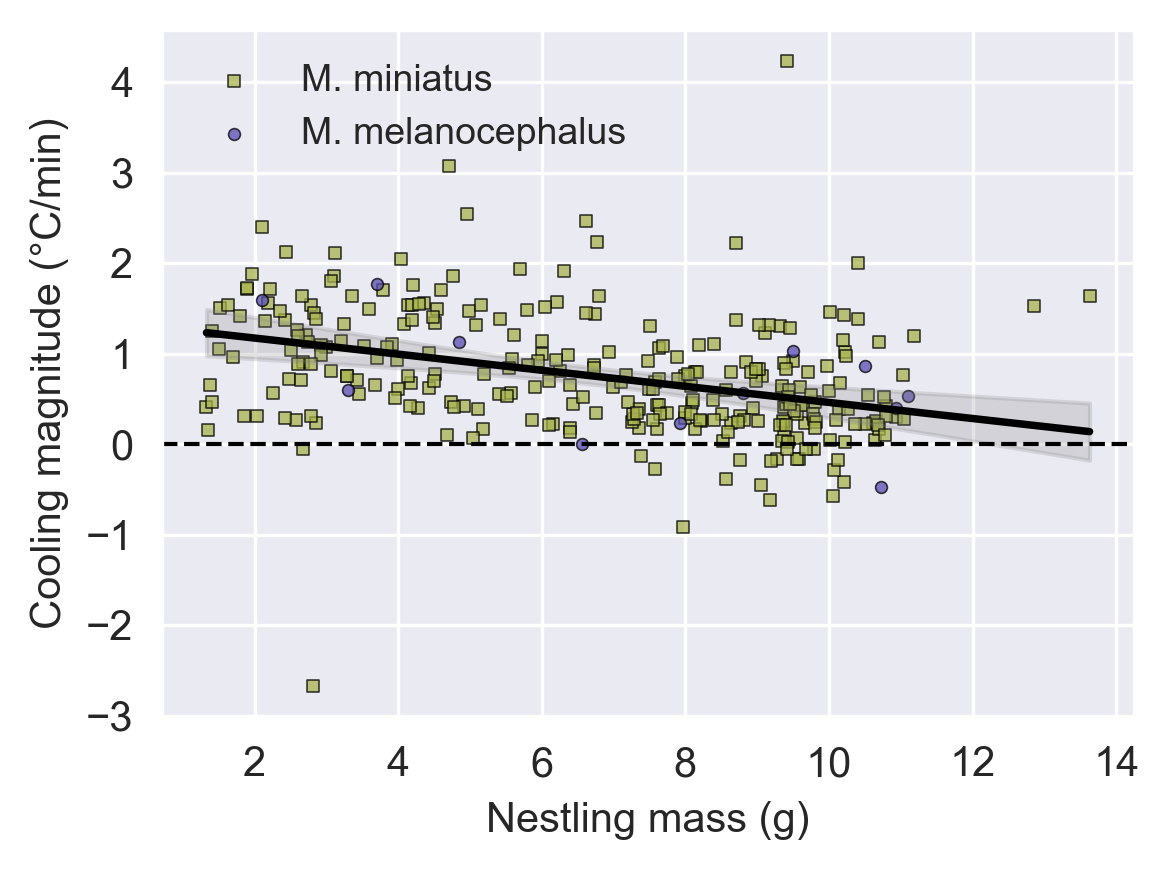

In [47]:
# Plot 3: effect of body mass
# ============================================================

mass_seq = np.linspace(
    df_model_re["Polluelo_Masa_g_c"].min(),
    df_model_re["Polluelo_Masa_g_c"].max(),
    100
)

pred_mass = pd.DataFrame({
    "thermal_gradient_initial_c": 0,
    "Edad_c": 0,
    "Polluelo_Masa_g_c": mass_seq
})

pred_mass["Polluelo_Masa_g"] = (
    pred_mass["Polluelo_Masa_g_c"] +
    df_model_re["Polluelo_Masa_g"].mean()
)

pred_mass = predict_mixedlm_ci(preferred_model, pred_mass)

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

for sp in df_model_re["Especie"].dropna().unique():
    sub = df_model_re[df_model_re["Especie"] == sp]
    ax.scatter(
        sub["Polluelo_Masa_g"],
        sub["cooling_magnitude_C_min"],
        alpha=0.75,
        s=8,
        marker=species_markers.get(sp, "o"),
        color=species_colors.get(sp, "gray"),
        edgecolor="black",
        linewidth=0.4,
        label=species_labels.get(sp, sp)
    )

ax.plot(
    pred_mass["Polluelo_Masa_g"],
    pred_mass["pred"],
    color="black",
    linewidth=1.8
)

ax.fill_between(
    pred_mass["Polluelo_Masa_g"],
    pred_mass["ci_low"],
    pred_mass["ci_high"],
    color="gray",
    alpha=0.22
)

ax.axhline(0, linestyle="--", linewidth=1, color="black")

ax.set_xlabel("Nestling mass (g)")
ax.set_ylabel("Cooling magnitude (°C/min)")

ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(
    "Figures/cloacal_cooling_effect_mass_species.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()

In [42]:
# Nest-level random effects from preferred model
# ============================================================

random_effects = preferred_model.random_effects

re_df = pd.DataFrame({
    "ID_del_Nido": list(random_effects.keys()),
    "random_intercept": [float(v.iloc[0]) for v in random_effects.values()]
})

re_df = re_df.sort_values("random_intercept").reset_index(drop=True)

nest_info = (
    df_model_re[["ID_del_Nido", "Especie", "Estacion", "Edad", "Polluelo_Masa_g"]]
    .groupby("ID_del_Nido")
    .agg(
        Especie=("Especie", "first"),
        Estacion=("Estacion", "first"),
        mean_age=("Edad", "mean"),
        mean_mass=("Polluelo_Masa_g", "mean"),
        n_obs=("Edad", "size")
    )
    .reset_index()
)

re_df_info = re_df.merge(nest_info, on="ID_del_Nido", how="left")

print("Most negative nest-level deviations: cooling less than expected")
print(re_df_info.head(10))

print("\nMost positive nest-level deviations: cooling more than expected")
print(re_df_info.tail(10))

Most negative nest-level deviations: cooling less than expected
   ID_del_Nido  random_intercept             Especie Estacion  mean_age  \
0    DA01_LP17         -0.246705  Myioborus_miniatus  Danubio  4.214286   
1   TA17_SLS15         -0.196807  Myioborus_miniatus   Tatama  4.333333   
2  TA50_ROAD15         -0.167881  Myioborus_miniatus   Tatama  6.500000   
3    DA02_LP17         -0.163694  Myioborus_miniatus  Danubio  5.166667   
4  TA41_MASM14         -0.154579  Myioborus_miniatus   Tatama  4.000000   
5   TA29_AMB15         -0.150996  Myioborus_miniatus   Tatama  3.500000   
6    TA02_RA15         -0.136142  Myioborus_miniatus   Tatama  8.333333   
7  TA09_GJDR14         -0.124463  Myioborus_miniatus   Tatama  1.500000   
8  TA35_ROAD15         -0.124280  Myioborus_miniatus   Tatama  6.333333   
9   TA19_MCD14         -0.122773  Myioborus_miniatus   Tatama  5.750000   

   mean_mass  n_obs  
0   7.429286     14  
1   6.220000      6  
2   6.567500      4  
3   8.623333      6  


In [43]:
n_extreme = 5

low_re = re_df_info.head(n_extreme).copy()
high_re = re_df_info.tail(n_extreme).copy()

low_re["direction"] = "Cooling less than expected"
high_re["direction"] = "Cooling more than expected"

extreme_re = pd.concat([low_re, high_re], ignore_index=True)

extreme_re = extreme_re[[
    "direction",
    "ID_del_Nido",
    "random_intercept",
    "Especie",
    "Estacion",
    "mean_age",
    "mean_mass",
    "n_obs"
]]

print(extreme_re)

extreme_re.to_csv("Figures/cloacal_cooling_random_effect_extremes.csv",index=False)

                    direction  ID_del_Nido  random_intercept  \
0  Cooling less than expected    DA01_LP17         -0.246705   
1  Cooling less than expected   TA17_SLS15         -0.196807   
2  Cooling less than expected  TA50_ROAD15         -0.167881   
3  Cooling less than expected    DA02_LP17         -0.163694   
4  Cooling less than expected  TA41_MASM14         -0.154579   
5  Cooling more than expected    W22_CJS10          0.151559   
6  Cooling more than expected   CH14_AMM15          0.199890   
7  Cooling more than expected   CH11_AMM15          0.280583   
8  Cooling more than expected   CH13_WTF15          0.320712   
9  Cooling more than expected    SP4_EJW11          0.322963   

                    Especie   Estacion  mean_age  mean_mass  n_obs  
0        Myioborus_miniatus    Danubio  4.214286   7.429286     14  
1        Myioborus_miniatus     Tatama  4.333333   6.220000      6  
2        Myioborus_miniatus     Tatama  6.500000   6.567500      4  
3        Myioborus_

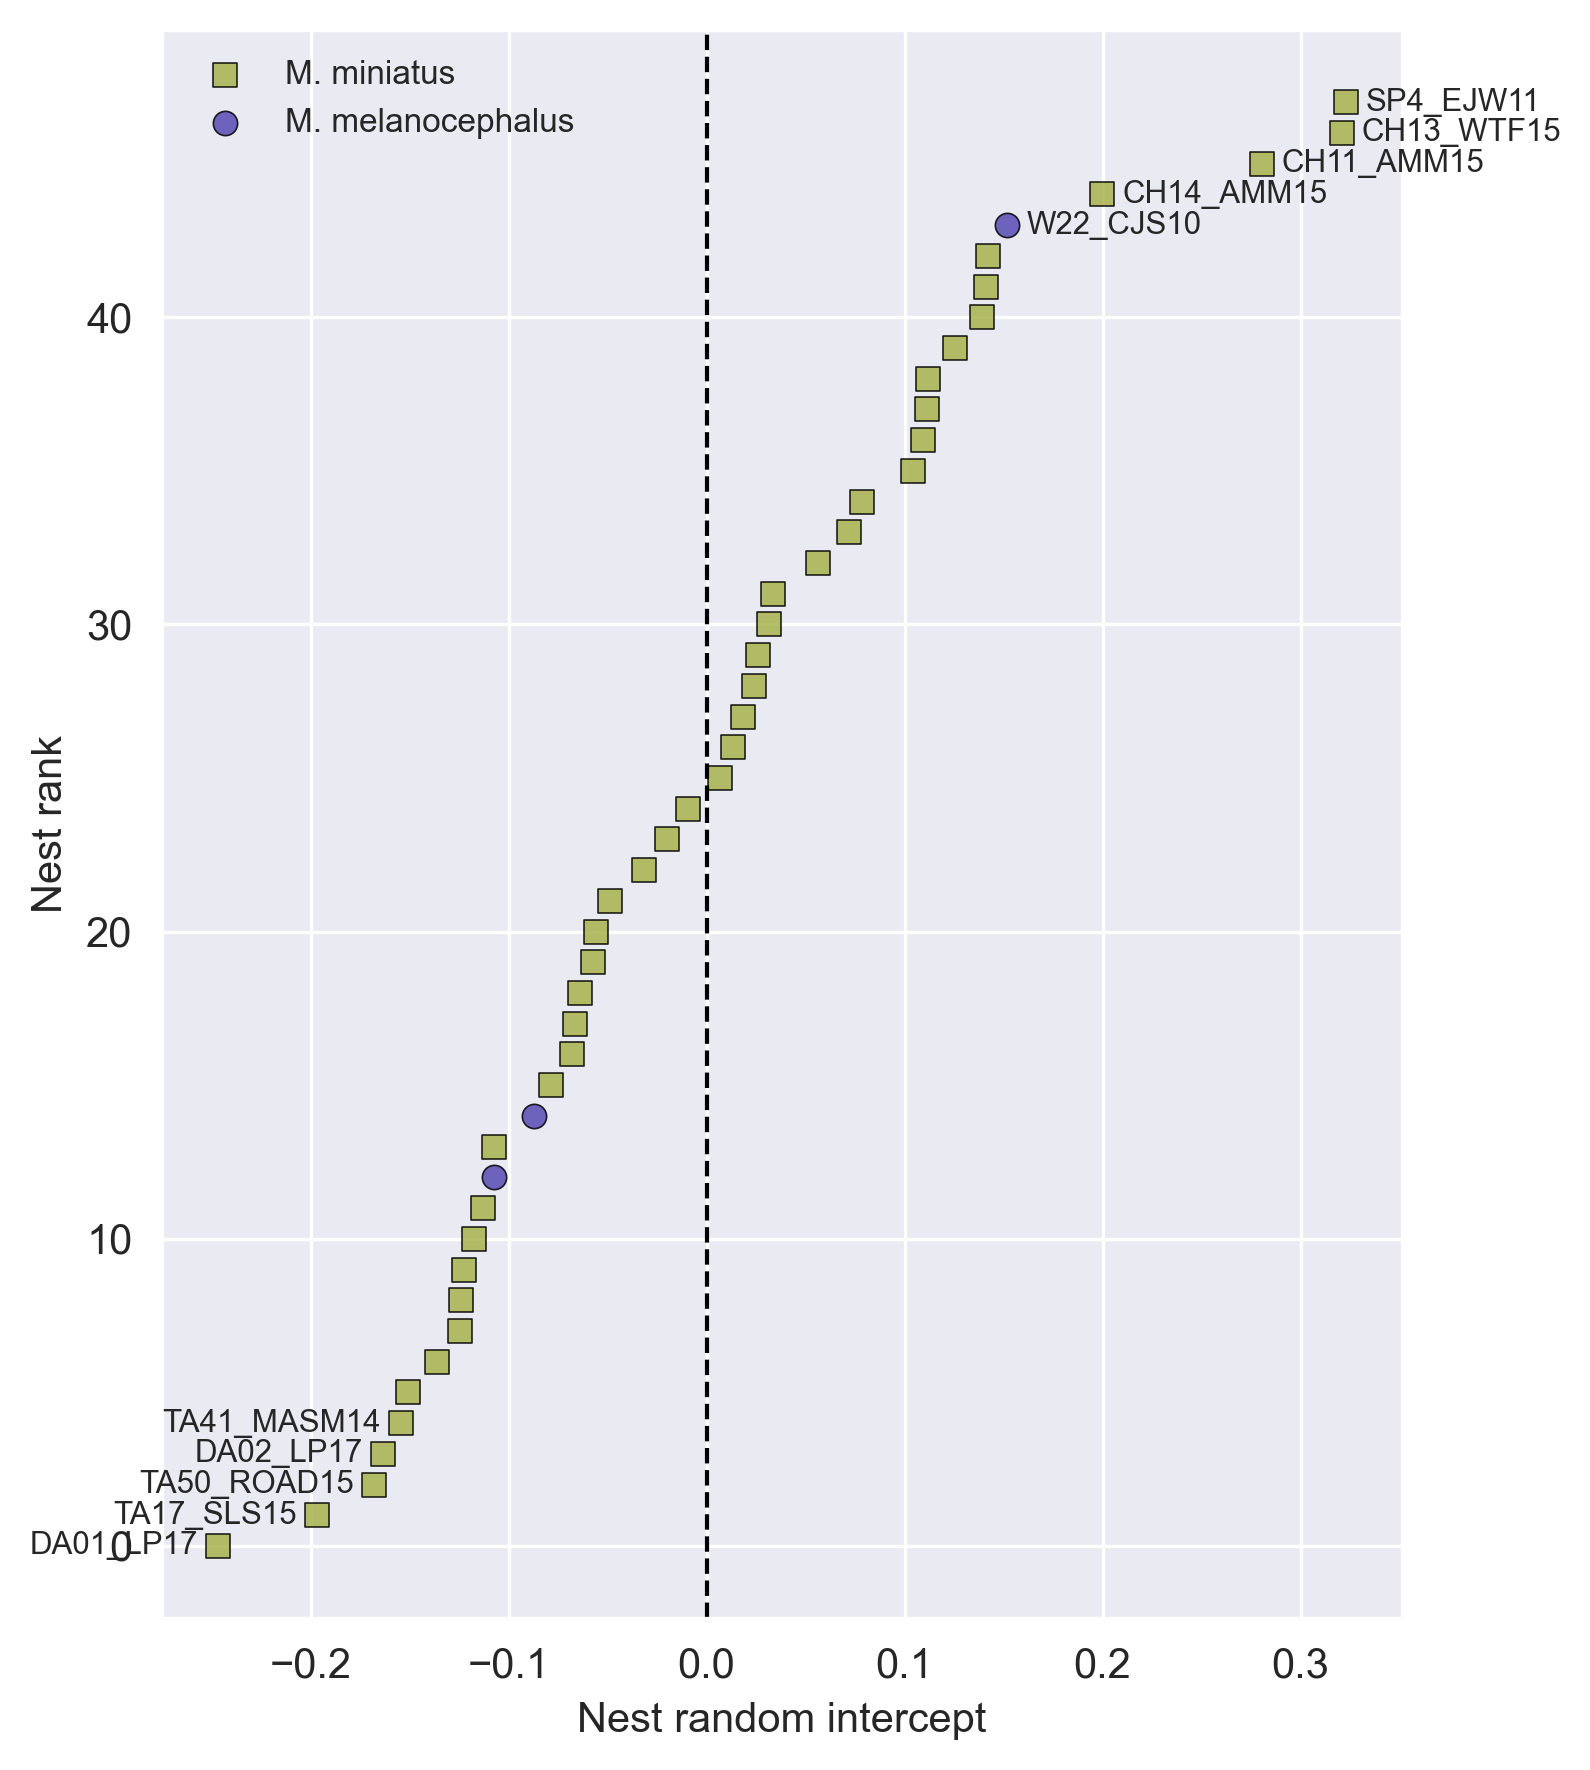

In [44]:
# Plot: nest random effects with labelled extremes
# ============================================================

species_labels = {
    'Myioborus_melanocephalus': 'M. melanocephalus',
    'Myioborus_miniatus': 'M. miniatus',
    'Myioborus_ornatus': 'M. ornatus'
}

species_markers = {
    'Myioborus_melanocephalus': 'o',
    'Myioborus_miniatus': 's',
    'Myioborus_ornatus': 'D'
}

species_colors = {
    'Myioborus_miniatus': "#A7B34C",
    'Myioborus_melanocephalus': "#584CB3",
    'Myioborus_ornatus': "#999999"
}

re_plot = re_df_info.sort_values("random_intercept").reset_index(drop=True)
re_plot["rank"] = np.arange(len(re_plot))

low_ids = set(re_plot.head(n_extreme)["ID_del_Nido"])
high_ids = set(re_plot.tail(n_extreme)["ID_del_Nido"])

fig, ax = plt.subplots(figsize=(5.4, 6.0), dpi=300)

for sp in re_plot["Especie"].dropna().unique():
    sub = re_plot[re_plot["Especie"] == sp]

    ax.scatter(
        sub["random_intercept"],
        sub["rank"],
        s=34,
        marker=species_markers.get(sp, "o"),
        color=species_colors.get(sp, "gray"),
        edgecolor="black",
        linewidth=0.4,
        alpha=0.85,
        label=species_labels.get(sp, sp)
    )

ax.axvline(0, linestyle="--", linewidth=1, color="black")

# Label only the extremes
for _, row in re_plot.iterrows():
    if row["ID_del_Nido"] in low_ids or row["ID_del_Nido"] in high_ids:
        x_offset = -0.01 if row["random_intercept"] < 0 else 0.01
        ha = "right" if row["random_intercept"] < 0 else "left"

        ax.text(
            row["random_intercept"] + x_offset,
            row["rank"],
            row["ID_del_Nido"],
            fontsize=7.5,
            ha=ha,
            va="center"
        )

ax.set_xlabel("Nest random intercept")
ax.set_ylabel("Nest rank")
ax.legend(frameon=False, fontsize=8, loc="best")

plt.tight_layout()
plt.savefig(
    "Figures/cloacal_cooling_random_effects_extremes.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()

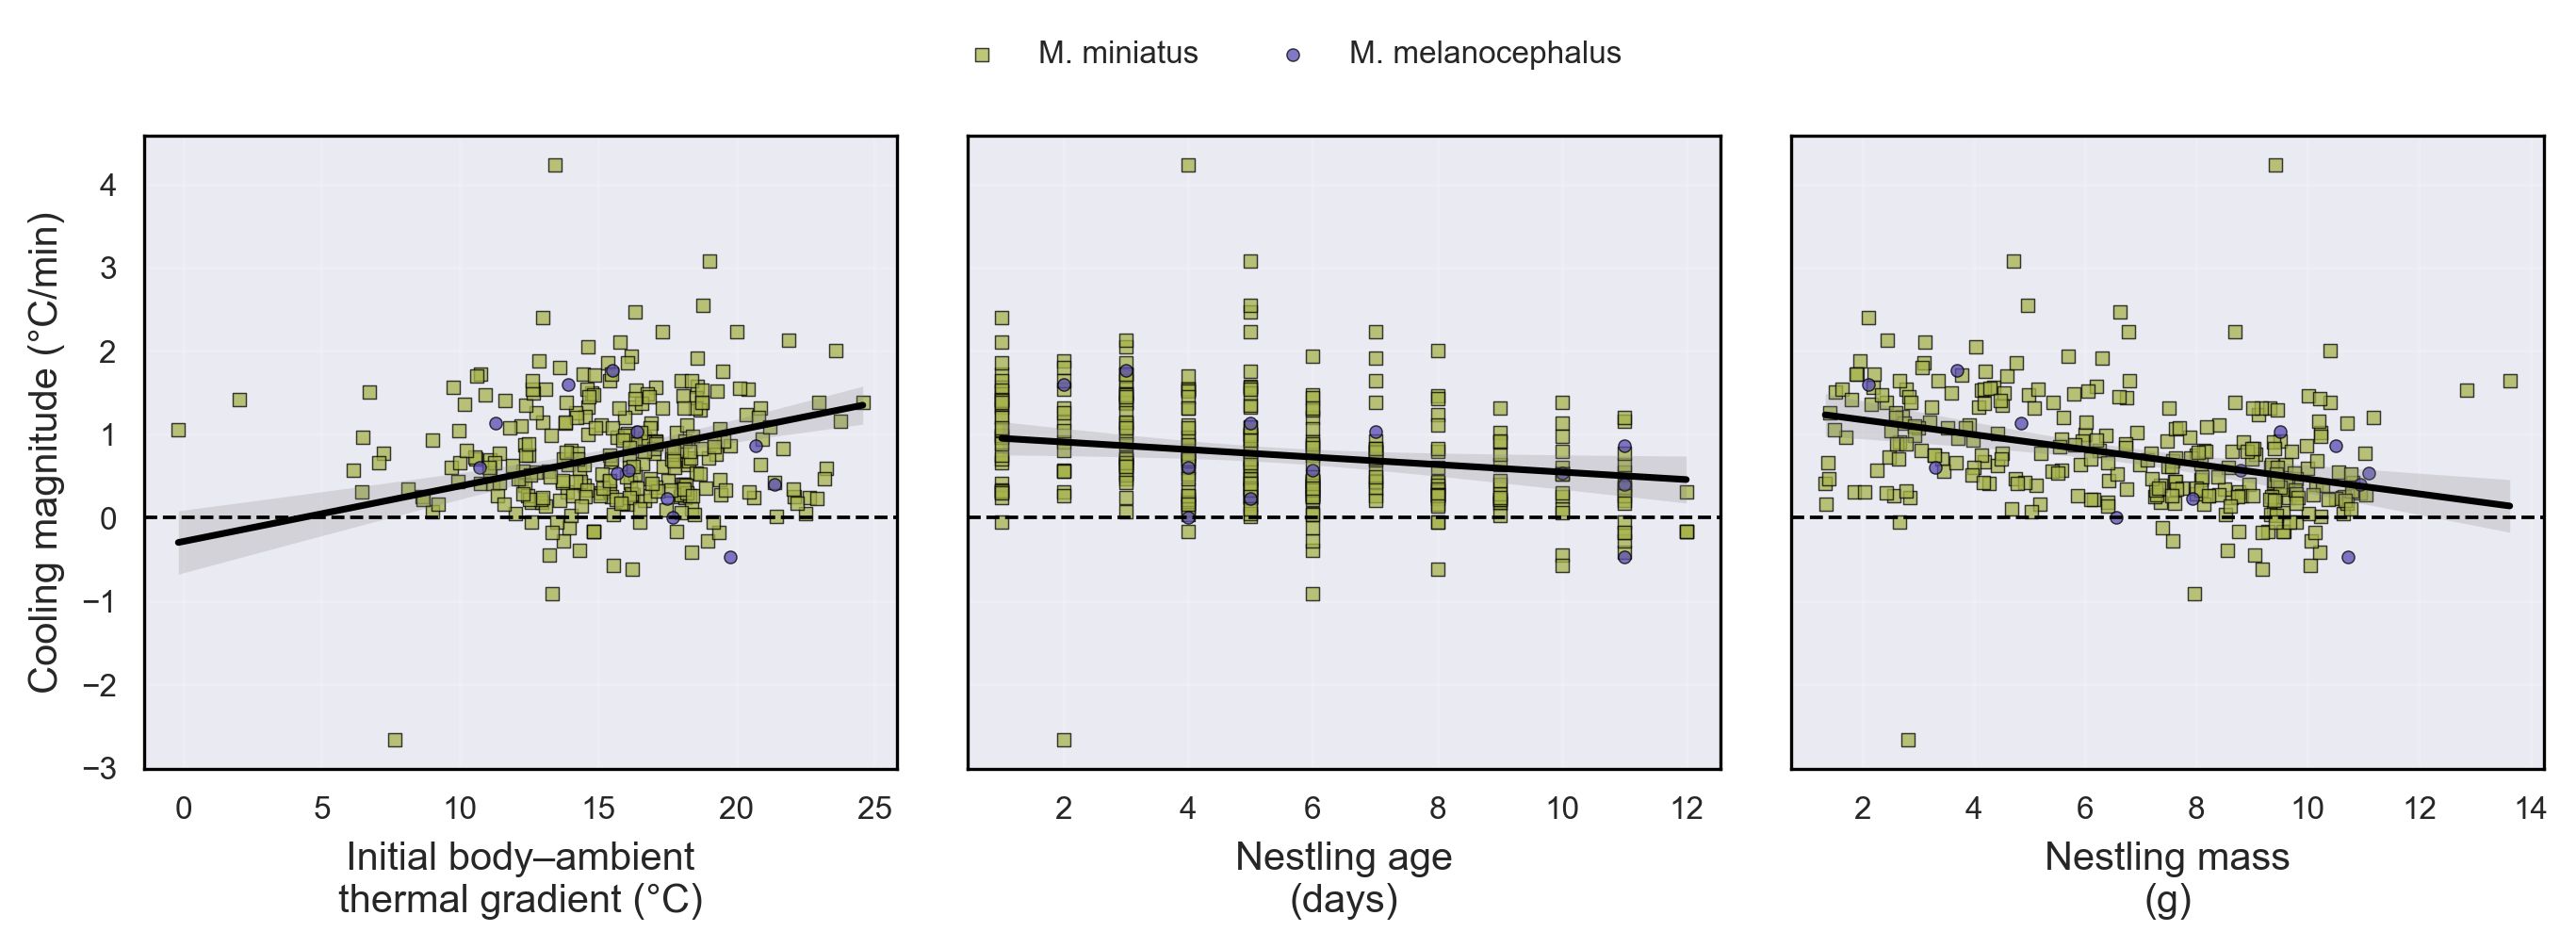

In [51]:
import os
os.makedirs("Figures", exist_ok=True)

# ------------------------------------------------------------
# Prediction data: thermal gradient
# ------------------------------------------------------------

gradient_seq = np.linspace(
    df_model_re["thermal_gradient_initial_c"].min(),
    df_model_re["thermal_gradient_initial_c"].max(),
    100
)

pred_gradient = pd.DataFrame({
    "thermal_gradient_initial_c": gradient_seq,
    "Edad_c": 0,
    "Polluelo_Masa_g_c": 0
})

pred_gradient["thermal_gradient_initial"] = (
    pred_gradient["thermal_gradient_initial_c"] +
    df_model_re["thermal_gradient_initial"].mean()
)

pred_gradient = predict_mixedlm_ci(preferred_model, pred_gradient)


# ------------------------------------------------------------
# Prediction data: age
# ------------------------------------------------------------

age_seq = np.linspace(
    df_model_re["Edad_c"].min(),
    df_model_re["Edad_c"].max(),
    100
)

pred_age = pd.DataFrame({
    "thermal_gradient_initial_c": 0,
    "Edad_c": age_seq,
    "Polluelo_Masa_g_c": 0
})

pred_age["Edad"] = pred_age["Edad_c"] + df_model_re["Edad"].mean()
pred_age = predict_mixedlm_ci(preferred_model, pred_age)


# ------------------------------------------------------------
# Prediction data: body mass
# ------------------------------------------------------------

mass_seq = np.linspace(
    df_model_re["Polluelo_Masa_g_c"].min(),
    df_model_re["Polluelo_Masa_g_c"].max(),
    100
)

pred_mass = pd.DataFrame({
    "thermal_gradient_initial_c": 0,
    "Edad_c": 0,
    "Polluelo_Masa_g_c": mass_seq
})

pred_mass["Polluelo_Masa_g"] = (
    pred_mass["Polluelo_Masa_g_c"] +
    df_model_re["Polluelo_Masa_g"].mean()
)

pred_mass = predict_mixedlm_ci(preferred_model, pred_mass)


# ------------------------------------------------------------
# Helper function for scatter by species
# ------------------------------------------------------------

def scatter_by_species(ax, x_col, y_col="cooling_magnitude_C_min", show_label=False):
    for sp in df_model_re["Especie"].dropna().unique():
        sub = df_model_re[df_model_re["Especie"] == sp]

        ax.scatter(
            sub[x_col],
            sub[y_col],
            alpha=0.75,
            s=10,
            marker=species_markers.get(sp, "o"),
            color=species_colors.get(sp, "gray"),
            edgecolor="black",
            linewidth=0.35,
            label=species_labels.get(sp, sp) if show_label else None
        )


# ------------------------------------------------------------
# Combined plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(9.2, 3.2),
    dpi=300,
    sharey=True
)

# Panel A: thermal gradient
ax = axes[0]

scatter_by_species(
    ax,
    x_col="thermal_gradient_initial",
    show_label=True
)

ax.plot(
    pred_gradient["thermal_gradient_initial"],
    pred_gradient["pred"],
    color="black",
    linewidth=1.7
)

ax.fill_between(
    pred_gradient["thermal_gradient_initial"],
    pred_gradient["ci_low"],
    pred_gradient["ci_high"],
    color="gray",
    alpha=0.22,
    linewidth=0
)

ax.axhline(0, linestyle="--", linewidth=0.9, color="black")

ax.set_xlabel("Initial body–ambient\nthermal gradient (°C)")
ax.set_ylabel("Cooling magnitude (°C/min)")
ax.text(
    0.03, 0.95, "",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)


# Panel B: age
ax = axes[1]

scatter_by_species(
    ax,
    x_col="Edad",
    show_label=False
)

ax.plot(
    pred_age["Edad"],
    pred_age["pred"],
    color="black",
    linewidth=1.7
)

ax.fill_between(
    pred_age["Edad"],
    pred_age["ci_low"],
    pred_age["ci_high"],
    color="gray",
    alpha=0.22,
    linewidth=0
)

ax.axhline(0, linestyle="--", linewidth=0.9, color="black")

ax.set_xlabel("Nestling age\n(days)")
ax.text(
    0.03, 0.95, "",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)


# Panel C: body mass
ax = axes[2]

scatter_by_species(
    ax,
    x_col="Polluelo_Masa_g",
    show_label=False
)

ax.plot(
    pred_mass["Polluelo_Masa_g"],
    pred_mass["pred"],
    color="black",
    linewidth=1.7
)

ax.fill_between(
    pred_mass["Polluelo_Masa_g"],
    pred_mass["ci_low"],
    pred_mass["ci_high"],
    color="gray",
    alpha=0.22,
    linewidth=0
)

ax.axhline(0, linestyle="--", linewidth=0.9, color="black")

ax.set_xlabel("Nestling mass\n(g)")
ax.text(
    0.03, 0.95, "",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    va="top"
)


# ------------------------------------------------------------
# Shared styling
# ------------------------------------------------------------

for ax in axes:
    ax.tick_params(axis="both", labelsize=8)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.grid(alpha=0.15)

# One legend only, from panel A
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=False,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "Figures/cloacal_cooling_fixed_effects_combined.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.savefig(
    "Figures/cloacal_cooling_fixed_effects_combined.pdf",
    transparent=True,
    bbox_inches="tight"
)

plt.show()